---
---

# <center>**⚖️ Justiça Preditiva: Análise e Mitigação de Viés Racial no Algoritmo COMPAS**

---
---

**Autor: Otávio Fabbro Machado**

> Este notebook é produto de um Trabalho de Conclusão de Curso do MBA em Ciência de Dados realizado no Instituto de Ciências Matemáticas e de Computação (ICMC-USP)

---
---

## **Metodologia: CRISP-DM**

Este projeto foi desenvolvido seguindo o **CRISP-DM** (*Cross Industry Standard Process for Data Mining*), 
uma metodologia amplamente adotada em projetos de Ciência de Dados que estrutura o trabalho em seis 
fases iterativas, garantindo rigor no processo e reprodutibilidade dos resultados.

| Fase CRISP-DM            | Seção deste notebook                                   |
|:-------------------------|:-------------------------------------------------------|
| Business Understanding   | 1 — Definição do Problema                              |
| Data Understanding       | 2 — Entendimento dos Dados                             |
| Data Preparation         | 3 — Preparação dos Dados                               |
| Modeling                 | 4 — Modelagem                                          |
| Evaluation               | 5 — Avaliação                                          |
| Deployment/Explainability| 6 — Explicabilidade e Interpretação                    |

</br>

> **Nota sobre a natureza iterativa:** O CRISP-DM não é linear. Neste projeto, os achados da fase de **Avaliação** retroalimentaram diretamente a fase de **Modelagem** — cada estratégia de mitigação de viés testada (pré-processamento, in-processing e pós-processamento) gerou um novo ciclo de avaliação, tornando explícitas as trocas (*trade-offs*) entre acurácia e justiça algorítmica.

</br>

---
---

---
---

# **1 - DEFINIÇÃO DO PROBLEMA**

> 📌 *Fase CRISP-DM: **Business Understanding** — Compreensão do contexto sociotécnico, definição dos objetivos e critérios de sucesso do projeto.*

---
---

## **TAREFAS:**

## 1.1 - Contextualizando

## 1.2 - O Domínio do Problema: Justiça Preditiva e Seus Riscos

## 1.3 - Objetivos do Projeto: Replicando e Expandindo a Análise "Machine Bias"

## 1.4 - Definindo "Justiça": Um Cenário Técnico e Social Disputado

## 1.5 - Critérios de Sucesso: Uma Estrutura de Avaliação Multifacetada

---
---

## **1.1 - Contextualizando**

**COMPAS** (*Correctional Offender Management Profiling for Alternative Sanctions*) é um algoritmo comercial popular usado por juízes e agentes de liberdade condicional para pontuar a probabilidade de reincidência de réus criminais. Foi demonstrado que o algoritmo é tendencioso a favor de réus brancos e contra detentos negros, com base em um estudo de acompanhamento de 2 anos (ou seja, quem realmente cometeu crimes ou crimes violentos após 2 anos). O padrão de erros, medido pela precisão/sensibilidade, é notável.

Citando a ProPublica:

> Réus negros eram frequentemente previstos como tendo um risco maior de reincidência do que realmente tinham. Nossa análise descobriu que réus negros que não reincidiram em um período de dois anos tinham quase o dobro da probabilidade de serem classificados erroneamente como de risco mais alto em comparação com seus pares brancos (45% vs. 23%).

> Réus brancos eram frequentemente previstos como menos arriscados do que eram. Nossa análise descobriu que réus brancos que reincidiram nos próximos dois anos foram erroneamente rotulados como de baixo risco quase o dobro de vezes que os reincidentes negros (48% vs. 28%).

> A análise também mostrou que, mesmo controlando por crimes anteriores, reincidência futura, idade e gênero, réus negros tinham 45% mais probabilidade de receber pontuações de risco mais altas do que réus brancos.

> *   Réus negros também tinham o dobro da probabilidade de serem classificados erroneamente como tendo um risco maior de reincidência violenta do que os brancos. E reincidentes violentos brancos tinham 63% mais probabilidade de terem sido classificados erroneamente como de baixo risco de reincidência violenta, em comparação com os reincidentes violentos negros.
> *   A análise de reincidência violenta também mostrou que, mesmo controlando por crimes anteriores, reincidência futura, idade e gênero, réus negros tinham 77% mais probabilidade de receber pontuações de risco mais altas do que réus brancos.

## **1.2 - O Domínio do Problema: Justiça Preditiva e Seus Riscos**

Nas últimas décadas, sistemas de justiça criminal em todo o mundo começaram a adotar ferramentas algorítmicas para apoiar a tomada de decisão. Uma dessas ferramentas é o **COMPAS** (*Correctional Offender Management Profiling for Alternative Sanctions*), um software desenvolvido para auxiliar juízes e oficiais de liberdade condicional a avaliar a probabilidade de um réu reincidir. A premissa fundamental por trás dessas ferramentas é substituir o julgamento humano, que pode ser suscetível a vieses cognitivos e inconsistências (como o "efeito do juiz faminto", onde decisões mais brandas são tomadas após uma refeição), por avaliações objetivas e baseadas em dados.


## **1.3 - Objetivos do Projeto: Replicando e Expandindo a Análise "Machine Bias"**

O objetivo principal deste projeto não é simplesmente prever a reincidência com a maior acurácia possível. Em vez disso, a tarefa de predição serve como um veículo para conduzir uma auditoria de justiça completa e detalhada. Construiremos um modelo preditivo e, em seguida, o avaliaremos rigorosamente em busca de vieses, com um foco particular nas disparidades raciais.

Os objetivos específicos são:

1.   Replicar os principais achados da análise da ProPublica, especialmente no que diz respeito às taxas de erro desiguais (falsos positivos e falsos negativos) entre diferentes grupos raciais.

2.   Investigar o contra-argumento da criadora do COMPAS, a Northpointe (agora Equivant), que defende a justiça do algoritmo com base na "paridade preditiva" ou calibração.

3.   Medir sistematicamente a justiça usando uma variedade de métricas fornecidas por toolkits modernos, como o Fairlearn, para obter uma visão multifacetada do comportamento do modelo.

4.  Explorar e avaliar a eficácia de diferentes estratégias de mitigação de viés, incluindo técnicas de pré-processamento, processamento e pós-processamento, para entender seus impactos tanto na justiça quanto na acurácia do modelo.

## **1.4 - Definindo "Justiça": Um Cenário Técnico e Social Disputado**

O cerne deste projeto reside em um conflito técnico e filosófico fundamental: não existe uma definição única e universalmente aceita de "justiça" algorítmica. Diferentes partes interessadas definem a justiça de maneiras que são, por vezes, matematicamente incompatíveis.

O Conflito Central:



*   A Posição da ProPublica (Igualdade de Erros): A análise da ProPublica focou nas taxas de erro. O achado mais contundente foi que réus negros que não reincidiram tinham quase o dobro da probabilidade de serem incorretamente classificados como de alto risco (uma alta Taxa de Falsos Positivos) em comparação com seus pares brancos (45% vs. 23%). Essa perspectiva se alinha com definições de justiça como Igualdade de Oportunidade (Equal Opportunity) ou Probabilidades Equalizadas (Equalized Odds), que exigem que as taxas de erro do modelo (FPR e FNR) sejam iguais entre os grupos.

*   A Posição da Northpointe (Paridade Preditiva): Em sua defesa, a Northpointe argumentou que a acurácia geral do COMPAS era semelhante para réus negros e brancos e, mais importante, que os escores eram bem calibrados. Isso significa que um escore de risco '7', por exemplo, correspondia a uma probabilidade semelhante de reincidência, independentemente da raça do réu. Essa definição é conhecida como Paridade Preditiva (Predictive Parity) ou Calibração.

<br>

**A Impossibilidade Matemática:**

Pesquisas subsequentes, inspiradas por este debate, revelaram uma verdade inconveniente: é matematicamente impossível para um modelo satisfazer simultaneamente a paridade preditiva e a igualdade nas taxas de erro quando as taxas de base do resultado (neste caso, a reincidência) diferem entre os grupos. Isso não é uma falha de um modelo específico como o COMPAS, mas uma propriedade inerente da estatística.

A escolha de uma métrica de justiça, portanto, não é uma decisão puramente técnica; é uma decisão ética implícita sobre qual tipo de erro é mais aceitável e qual grupo deve arcar com o ônus dos erros inevitáveis do modelo. Um modelo é uma ferramenta para gerenciar incertezas e sempre cometerá erros. Os dois tipos principais de erro são Falsos Positivos (prever reincidência para alguém que não irá reincidir) e Falsos Negativos (prever não reincidência para alguém que irá). Priorizar a Igualdade de Probabilidades (visão da ProPublica) significa que o dano de um Falso Positivo (por exemplo, uma negação injusta de liberdade condicional) deve ser distribuído igualmente entre os grupos raciais, mesmo que isso signifique que o poder preditivo do escore varie entre os grupos. Por outro lado, priorizar a Paridade Preditiva (visão da Northpointe) significa que o "significado" de um escore de risco deve ser consistente para todos. O dano aqui é que, para alcançar essa consistência com taxas de base desiguais, o modelo deve ter uma Taxa de Falsos Positivos mais alta para o grupo com a maior taxa de base.

O cientista de dados ou o formulador de políticas é forçado a escolher: queremos escores que sejam igualmente "significativos" ou igualmente "errados"? Esta é uma decisão de valor, não um problema de otimização técnica. Consequentemente, este projeto não buscará um único modelo "justo", mas apresentará um portfólio de modelos, cada um otimizado para uma definição diferente de justiça, a fim de tornar essas trocas explícitas.

## **1.5 - Critérios de Sucesso: Uma Estrutura de Avaliação Multifacetada**

O sucesso deste projeto não será medido por uma única métrica como acurácia ou AUC. Em vez disso, adotaremos uma avaliação holística baseada nos seguintes critérios:

1.  Clareza da Auditoria de Justiça: A capacidade de quantificar com sucesso o viés no modelo de base através de múltiplas métricas (FPR, FNR, taxa de seleção, etc.), desagregadas por raça e sexo.

2.  Demonstração da Troca (Trade-off): A habilidade de visualizar e explicar claramente o conflito inerente entre a paridade preditiva e o equilíbrio da taxa de erro.

3.  Eficácia da Mitigação: Avaliar como diferentes estratégias de mitigação de viés impactam tanto a acurácia do modelo quanto as várias métricas de justiça.

4.  Qualidade do Relatório: Produzir um notebook bem documentado e reprodutível que explique claramente o contexto sociotécnico, os passos técnicos e as implicações matizadas dos achados.

---
---

# **2 - ENTENDIMENTO DOS DADOS**

> 📌 *Fase CRISP-DM: **Data Understanding** — Coleta, exploração e análise descritiva dos dados para identificar padrões e relações com a variável alvo.*

---
---

## **OBJETIVO: Coletar e fazer uma análise exploratória dos dados visando encontrar relações entre a variável objetivo (Labels) e as covariáveis (Features)**

---

## **TAREFAS**

## 2.1 - Coleta dos dados

## 2.2 - Dicionário e estrutura do conjunto de dados

## 2.3 - Análise descritiva univariada das variáveis

## 2.4 - Análise das features comparada com a variável resposta

## 2.5 - Análise de interação entre as features

---
---



## **2.1 - Coleta dos dados**

Os dados incluem variáveis utilizadas pelo algoritmo COMPAS para pontuar réus, juntamente com os resultados em até 2 anos após a decisão, para mais de 10.000 réus criminais no Condado de Broward, Flórida.

Foram fornecidos três subconjuntos dos dados, incluindo um subconjunto apenas de **reincidência violenta** (em oposição, por exemplo, a ser reencarcerado por delitos não violentos, como vadiagem ou porte de maconha).

Uma análise aprofundada feita pela ProPublica pode ser encontrada no [artigo sobre a metodologia dos dados](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm) deles.

### **2.1.1 - Observações**

Dados e análise original coletados pela ProPublica.

*   [Artigo original sobre metodologia de dados](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm)

*   [Artigo original](https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing)

*   [Dados originais da ProPublica](https://github.com/propublica/compas-analysis)

*   [Subconjunto "simples" adicional fornecido pela FairML, com base nos dados da ProPublica](https://blog.fastforwardlabs.com/2017/03/09/fairml-auditing-black-box-predictive-models.html)


## **2.2 - Dicionário de Dados e Análise de Variáveis**

Para manter a clareza e a reprodutibilidade, é essencial definir as variáveis-chave que serão usadas em nossa análise. A tabela a seguir resume as colunas mais importantes, com base na documentação disponível e na análise da ProPublica. Um dicionário de dados focado ajuda a destilar a complexidade das 53 colunas em um conjunto gerenciável e compreensível.

<br>

| Nome da Coluna | Tipo de Dado | Descrição | Relevância |
| :--- | :--- | :--- | :--- |
| `age` | inteiro | Idade do réu no momento da avaliação. | Fator demográfico chave e um forte preditor de reincidência. |
| `c_charge_degree` | string | Gravidade da acusação (ex: 'F' para Felony, 'M' para Misdemeanor). | Indicador da severidade do crime. |
| `race` | string | Raça do réu (ex: 'African-American', 'Caucasian'). | O atributo protegido primário para nossa auditoria de justiça. |
| `sex` | string | Sexo do réu ('Male', 'Female'). | Um atributo protegido secundário. |
| `priors_count` | inteiro | Número de crimes anteriores registrados. | Um preditor crítico de reincidência futura. |
| `days_b_screening_arrest` | inteiro | Dias entre a prisão e a avaliação COMPAS. Usado para limpeza de dados. | Filtro de qualidade dos dados. |
| `decile_score` | inteiro | O escore de risco COMPAS de 1 (baixo risco) a 10 (alto risco). | A saída do algoritmo que estamos avaliando. |
| `score_text` | string | O nível de risco categórico ('Low', 'Medium', 'High'). | A versão categórica do `decile_score`. |
| `two_year_recid` | inteiro | 1 se o réu reincidiu em dois anos, 0 caso contrário. | Nossa variável alvo (a "verdade fundamental"). |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Lendo o conjunto de dados
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
dados = pd.read_csv(url)

# Verificando as dimensões do DataFrame
print(f'CONJUNTO DE DADOS \nVariáveis: \t{dados.shape[1]} \nObservações: \t{dados.shape[0]}\n')

CONJUNTO DE DADOS 
Variáveis: 	53 
Observações: 	7214



## Principais Bibliotecas Utilizadas

Neste trabalho, diversas bibliotecas Python foram empregadas para manipulação, análise e visualização de dados, além de modelagem de Machine Learning e mitigação de viés. As principais são:

*   **`pandas`**: Essencial para manipulação e análise de dados. Oferece estruturas de dados flexíveis e eficientes, como DataFrames, que facilitam a leitura, limpeza, transformação e agregação de dados.
*   **`numpy`**: Biblioteca fundamental para computação numérica em Python. Fornece suporte para arrays e matrizes, além de uma vasta coleção de funções matemáticas para operar sobre esses dados.
*   **`matplotlib.pyplot`**: Uma biblioteca de visualização de dados que permite criar gráficos estáticos, animados e interativos em Python. É utilizada para personalizar e exibir os gráficos gerados.
*   **`seaborn`**: Construída sobre o `matplotlib`, o `seaborn` oferece uma interface de alto nível para desenhar gráficos estatísticos atraentes e informativos. Simplifica a visualização de relações complexas nos dados.
*   **`xgboost`**: Uma implementação otimizada de algoritmos de gradient boosting. Conhecida por sua alta performance e eficiência, é amplamente utilizada em problemas de classificação e regressão, especialmente com dados que possuem não-linearidades e interações complexas.
*   **`fairlearn`**: Uma biblioteca que capacita desenvolvedores de sistemas de IA a avaliar e melhorar a equidade de seus modelos. Contém algoritmos de mitigação de viés que ajudam a garantir que os modelos se comportem de forma justa entre diferentes grupos.
*   **`sklearn` (Scikit-learn)**: Uma biblioteca abrangente para Machine Learning em Python. Oferece uma ampla gama de algoritmos de classificação, regressão, clustering, redução de dimensionalidade, bem como ferramentas para pré-processamento de dados e avaliação de modelos. Partes como `train_test_split` são amplamente utilizadas.
*   **`shap` (SHapley Additive exPlanations)**: Uma ferramenta de explicabilidade que ajuda a entender como cada característica individual (feature) contribui para a previsão de um modelo de Machine Learning. É fundamental para abrir a 'caixa preta' de modelos complexos e entender seus comportamentos.

In [ ]:
print("\nTipos de Dados e Valores Não Nulos:")
dados.info()


Tipos de Dados e Valores Não Nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   object 
 2   first                    7214 non-null   object 
 3   last                     7214 non-null   object 
 4   compas_screening_date    7214 non-null   object 
 5   sex                      7214 non-null   object 
 6   dob                      7214 non-null   object 
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   object 
 9   race                     7214 non-null   object 
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-null   

In [ ]:
import pandas as pd

# Lendo o conjunto de dados para garantir que 'dados' esteja definido
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
dados = pd.read_csv(url)

print("\nPrimeiras 5 Linhas do Dataset com Variáveis Relevantes:")
relevant_columns = ['age', 'c_charge_degree', 'race', 'sex', 'priors_count', 'days_b_screening_arrest', 'decile_score', 'score_text', 'two_year_recid']
display(dados[relevant_columns].head())


Primeiras 5 Linhas do Dataset com Variáveis Relevantes:


,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,decile_score,score_text,two_year_recid
0,69,F,Other,Male,0,-1.0,1,Low,0
1,34,F,African-American,Male,0,-1.0,3,Low,1
2,24,F,African-American,Male,4,-1.0,4,Low,1
3,23,F,African-American,Male,1,NaN,8,High,0
4,43,F,Other,Male,2,NaN,1,Low,0


In [ ]:
print("\nEstatísticas Descritivas para Colunas Numéricas:")
display(dados[relevant_columns].describe())


Estatísticas Descritivas para Colunas Numéricas:


,age,priors_count,days_b_screening_arrest,decile_score,two_year_recid
count,7214.000000,7214.000000,6907.000000,7214.000000,7214.000000
mean,34.817993,3.472415,3.304763,4.509565,0.450652
std,11.888922,4.882538,75.809505,2.856396,0.497593
min,18.000000,0.000000,-414.000000,1.000000,0.000000
25%,25.000000,0.000000,-1.000000,2.000000,0.000000
50%,31.000000,2.000000,-1.000000,4.000000,0.000000
75%,42.000000,5.000000,0.000000,7.000000,1.000000
max,96.000000,38.000000,1057.000000,10.000000,1.000000


## **2.3 - Análise Exploratória de Dados (AED): Descobrindo Padrões Fundamentais**

O objetivo desta AED é confirmar visual e estatisticamente as premissas centrais da investigação da ProPublica.

### **2.3.1 - Distribuição dos Escores de Risco por Raça**

Vamos plotar a distribuição dos escores de decil (`decile_score`) para réus negros e brancos. A expectativa é encontrar distribuições diferentes, com os réus negros apresentando uma tendência a escores mais altos.

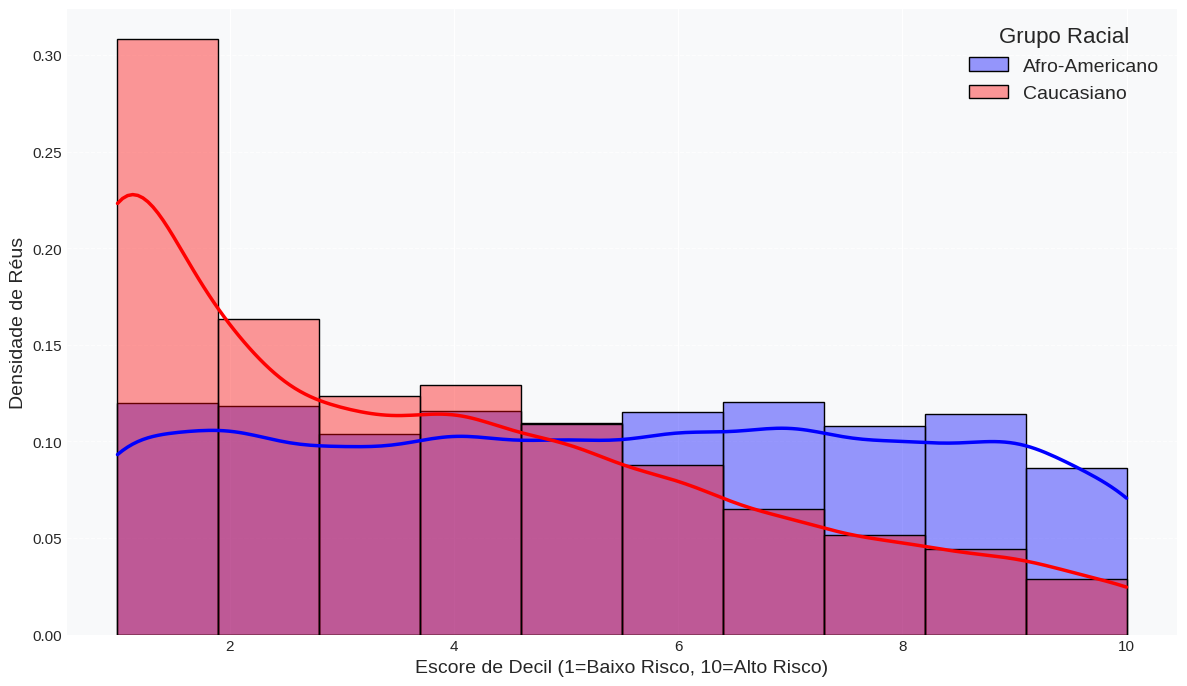

In [ ]:
plt.figure(figsize=(12, 7))

# Filtra para os dois grupos de maior interesse na análise
df_aa = dados[dados['race'] == 'African-American']
df_cau = dados[dados['race'] == 'Caucasian']

sns.histplot(df_aa['decile_score'], color='blue', label='Afro-Americano', kde=True, stat='density', bins=10, alpha=0.4, line_kws={'linewidth': 2.5}, fill=True)
sns.histplot(df_cau['decile_score'], color='red', label='Caucasiano', kde=True, stat='density', bins=10, alpha=0.4, line_kws={'linewidth': 2.5}, fill=True)

# plt.title('Distribuição Comparativa dos Escores de Risco COMPAS por Raça', fontsize=14, fontweight='bold')
plt.xlabel('Escore de Decil (1=Baixo Risco, 10=Alto Risco)', fontsize=14)
plt.ylabel('Densidade de Réus', fontsize=14)
plt.legend(title='Grupo Racial', fontsize=14, title_fontsize='16') # Aumentado o tamanho da fonte da legenda e do título
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.tight_layout()
plt.savefig('fig01.png', bbox_inches='tight', dpi=800)
plt.show()

O gráfico confirma a expectativa: a distribuição dos escores para réus afro-americanos é visivelmente deslocada para a direita (escores mais altos) em comparação com a distribuição para réus caucasianos, que é mais concentrada em escores mais baixos.

### **2.3.2 - Taxas Base de Reincidência por Raça**

Agora, vamos calcular a taxa real de reincidência em dois anos (`two_year_recid`) para cada grupo racial. Isso estabelece as "taxas de base" desiguais que são centrais para o paradoxo da justiça.



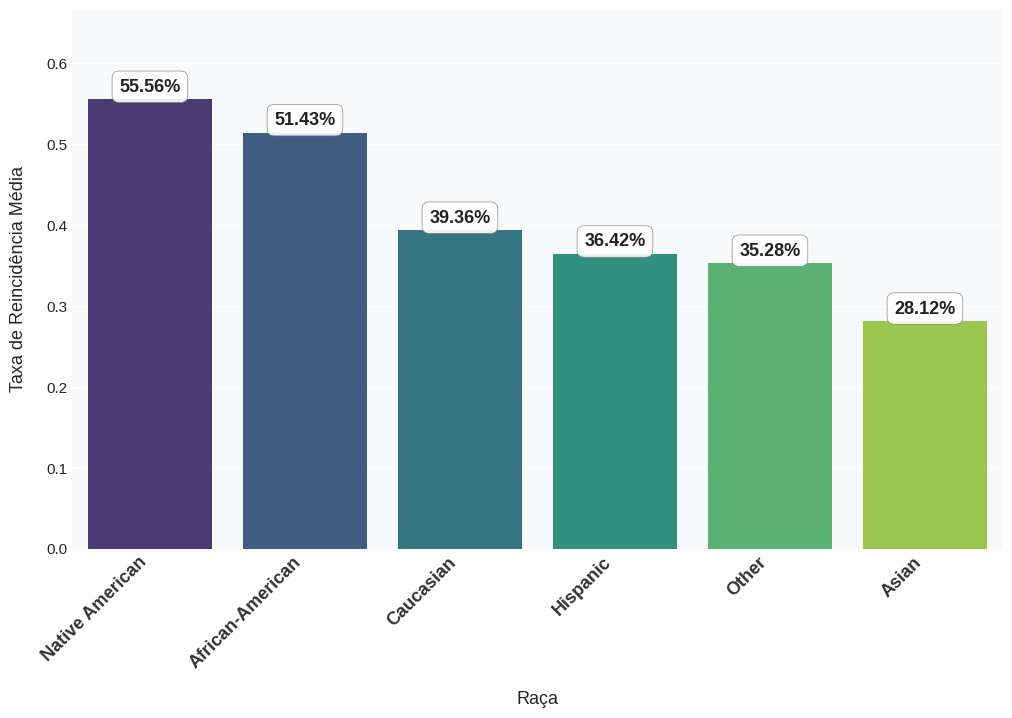


Taxas de Reincidência por Raça:
race
Native American     0.555556
African-American    0.514340
Caucasian           0.393643
Hispanic            0.364207
Other               0.352785
Asian               0.281250
Name: two_year_recid, dtype: float64


In [ ]:
recid_rates = dados.groupby('race')['two_year_recid'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 7))

palette = sns.color_palette('viridis', n_colors=len(recid_rates))
barplot = sns.barplot(x=recid_rates.index, y=recid_rates.values, palette=palette, hue=recid_rates.index, legend=False)

plt.ylabel('Taxa de Reincidência Média', labelpad=14, fontsize=13)
plt.xlabel('Raça', labelpad=14, fontsize=13)

# Labels do eixo X em preto (melhor contraste)
plt.xticks(rotation=45, ha='right', fontsize=13, fontweight='bold', color='#333333')

# Porcentagens em preto sobre fundo branco suave
for index, value in enumerate(recid_rates):
    text = plt.text(index, value + 0.01, f'{value:.2%}',
                    ha='center', fontsize=13, fontweight='bold',
                    color='#222222')
    text.set_bbox(dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='gray', linewidth=0.5))

plt.ylim(0, recid_rates.max() * 1.2)
plt.savefig('fig02.png', bbox_inches='tight', dpi=800)
plt.show()

print("\nTaxas de Reincidência por Raça:")
print(recid_rates)

A análise das taxas de base revela uma disparidade significativa. No dataset, réus afro-americanos têm uma taxa de reincidência de aproximadamente 51.4%, enquanto réus caucasianos têm uma taxa de 39.4%. Essa diferença nas taxas de base é um fato estatístico crucial que, como veremos, torna impossível satisfazer simultaneamente todas as noções de justiça.

### **2.3.3 - Relação entre Histórico Criminal e Raça**

Uma pergunta importante é se os escores de risco mais altos para um grupo são simplesmente um reflexo de históricos criminais mais extensos. Vamos analisar a distribuição do número de antecedentes (`priors_count`) entre os grupos.

/tmp/ipython-input-3209802811.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(


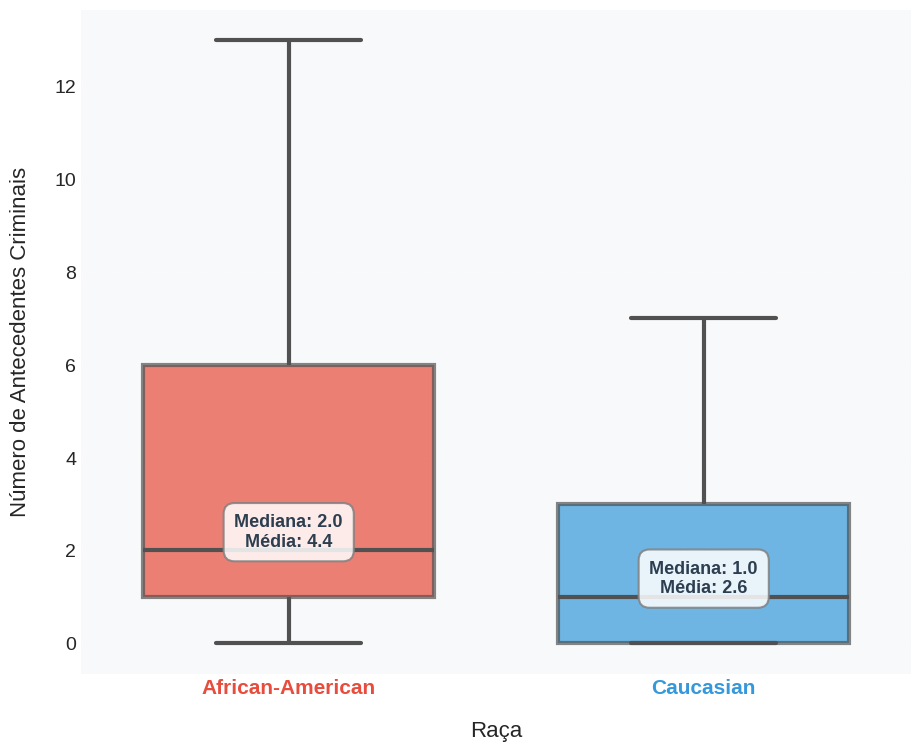


Estatísticas Descritivas por Raça:

African-American:
  Mediana: 2.00
  Média: 4.44
  Desvio Padrão: 5.58
  Q1 (25%): 1.00
  Q3 (75%): 6.00

Caucasian:
  Mediana: 1.00
  Média: 2.59
  Desvio Padrão: 3.80
  Q1 (25%): 0.00
  Q3 (75%): 3.00


In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

# Filtra os dados
dados_filtrados = dados[dados['race'].isin(['African-American', 'Caucasian'])]

# Define cores distintas e elegantes
cores = {'African-American': '#E74C3C', 'Caucasian': '#3498DB'}
palette = [cores['African-American'], cores['Caucasian']]

# Aumenta o tamanho da figura
plt.figure(figsize=(10, 8))

# Cria o boxplot com caixas mais largas
box = sns.boxplot(
    x='race',
    y='priors_count',
    data=dados_filtrados,
    palette=palette,
    showfliers=False,
    width=0.7,
    linewidth=3
)

# Customiza as cores das caixas com transparência
for patch, color in zip(box.patches, palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Adiciona grid horizontal suave para facilitar leitura
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
box.set_axisbelow(True)

# Labels com fontes maiores
plt.xlabel('Raça', fontsize=16, labelpad=17)
plt.ylabel('Número de Antecedentes Criminais', fontsize=16, labelpad=17)

# Customiza os labels do eixo X com cores correspondentes e fonte maior
ax = plt.gca()
for tick_label, race in zip(ax.get_xticklabels(), ['African-American', 'Caucasian']):
    tick_label.set_color(cores[race])
    tick_label.set_fontweight('bold')
    tick_label.set_fontsize(15)  # Aumentado de 12 para 15

# Aumenta o tamanho da fonte do eixo Y
plt.yticks(fontsize=14)  # Aumentado de 11 para 14

# Adiciona estatísticas descritivas como anotações com fonte maior
for i, race in enumerate(['African-American', 'Caucasian']):
    median = dados_filtrados[dados_filtrados['race'] == race]['priors_count'].median()
    mean = dados_filtrados[dados_filtrados['race'] == race]['priors_count'].mean()

    # Texto com fundo semi-transparente e fonte maior
    text = plt.text(i, median, f'Mediana: {median:.1f}\nMédia: {mean:.1f}',
                    ha='center', va='bottom', fontsize=13, fontweight='bold',  # Aumentado de 10 para 13
                    color='#2C3E50')
    text.set_bbox(dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.85,
                       edgecolor='gray', linewidth=1.5))

# Ajusta as margens
plt.tight_layout()
plt.subplots_adjust(left=0.12, right=0.95, top=0.95, bottom=0.12)

plt.savefig('fig03.png', bbox_inches='tight', dpi=800)
plt.show()

# Exibe estatísticas detalhadas
print("\nEstatísticas Descritivas por Raça:")
print("="*60)
for race in ['African-American', 'Caucasian']:
    dados_race = dados_filtrados[dados_filtrados['race'] == race]['priors_count']
    print(f"\n{race}:")
    print(f"  Mediana: {dados_race.median():.2f}")
    print(f"  Média: {dados_race.mean():.2f}")
    print(f"  Desvio Padrão: {dados_race.std():.2f}")
    print(f"  Q1 (25%): {dados_race.quantile(0.25):.2f}")
    print(f"  Q3 (75%): {dados_race.quantile(0.75):.2f}")

O boxplot apresentado ilustra a distribuição do número de antecedentes criminais segundo raça, considerando as categorias "African-American" (negros) e "Caucasian" (brancos) e com exclusão de outliers, de modo a privilegiar a análise da tendência central e da dispersão dos dados.

Observa-se que o grupo classificado como "African-American" apresenta mediana superior de antecedentes criminais em comparação classificado como "Caucasian", bem como maior amplitude interquartílica, indicando maior variabilidade interna. Mesmo após a remoção de valores extremos, esse grupo mantém uma distribuição mais dispersa e com valores máximos substancialmente mais elevados, o que sugere a presença de um subconjunto de indivíduos com histórico criminal mais extenso dentro da amostra analisada.

O grupo "Caucasian" exibe distribuição mais concentrada em valores baixos, com mediana próxima de um antecedente criminal e amplitude interquartílica reduzida. A maior parte das observações situa-se entre zero e dois antecedentes, indicando menor variabilidade quando comparados ao grupo "African-American". Embora existam casos com maior número de antecedentes nesses grupos, eles são menos frequentes e apresentam menor alcance máximo.

Do ponto de vista comparativo, os resultados indicam diferenças sistemáticas na distribuição do número de antecedentes criminais entre os grupos raciais, particularmente no que se refere à dispersão e à posição da mediana. Todavia, tais diferenças não devem ser interpretadas como reflexo direto de propensões individuais ou características inerentes aos grupos analisados. O número de antecedentes criminais é um indicador fortemente condicionado por fatores estruturais, como padrões diferenciados de policiamento, desigualdades socioeconômicas, seletividade penal e possíveis vieses institucionais no sistema de justiça criminal.

## **2.4 - Qualidade dos Dados e Limitações Inerentes**

É fundamental reconhecer as limitações dos dados com os quais estamos trabalhando. A própria ProPublica realizou uma filtragem significativa para remover registros que consideraram de baixa qualidade ou irrelevantes. Adotaremos um processo de limpeza semelhante na próxima fase.

No entanto, existe uma limitação mais profunda e conceitual que deve ser abordada. A variável alvo, `two_year_recid`, não é uma medida objetiva de "reincidência criminal". É uma medida de nova prisão dentro de dois anos. Essa distinção é crítica e frequentemente perdida em discussões de alto nível. O objetivo declarado do COMPAS é prever o risco de cometer um novo crime. Contudo, não possuímos dados sobre todos os crimes cometidos; temos apenas dados sobre prisões. As taxas de prisão são influenciadas por padrões de policiamento, relações comunitárias com a polícia e vieses sociais existentes. Se uma comunidade é policiada mais intensamente, seus residentes têm maior probabilidade de serem presos, independentemente de sua taxa subjacente de atividade criminosa.

Portanto, **o modelo que construiremos não está aprendendo a prever a reincidência, mas sim a prever *quem tem maior probabilidade de ser preso***. Se os dados de treinamento refletem um policiamento enviesado, o modelo aprenderá a replicar e potencialmente amplificar esse viés. Ele parecerá "acurado" na previsão de prisões, enquanto codifica a mesma desigualdade sistêmica que deveria ajudar a superar. Esta é uma limitação fundamental do projeto. Devemos declarar abertamente que qualquer modelo construído, não importa quão "justo" de acordo com as métricas, é construído sobre uma base de dados proxy potencialmente enviesada. Isso modera qualquer alegação de "resolver" o problema do viés e destaca a necessidade de uma solução sociotécnica, e não apenas técnica

---
---

## **3 - PREPARAÇÃO DOS DADOS**

> 📌 *Fase CRISP-DM: **Data Preparation** — Limpeza, filtragem, engenharia de features e divisão do conjunto de dados para modelagem.*

---
---

### **OBJETIVO: Preparar o conjunto de dados para aplicação dos modelos de aprendizado de máquina**

---

### **TAREFAS**

### - Limpeza e Filtragem de Dados: Alinhamento com a Metodologia da ProPublica

### - Engenharia e Seleção de Features

### - Transformação e Codificação de Dados

### - Divisão do Dataset para Modelagem e Avaliação

---
---

### **3.1 - Limpeza e Filtragem de Dados: Alinhamento com a Metodologia da ProPublica**

Para dialogar de forma significativa com o artigo original "Machine Bias", devemos analisar uma população comparável. A ProPublica aplicou vários filtros para remover o que consideraram ser ruído ou erros de qualidade de dados.




1. **Janela Temporal:** Mantemos apenas casos onde a avaliação do COMPAS ocorreu
dentro de 30 dias da prisão (`days_b_screening_arrest`), garantindo conexão causal.

2. **Gravidade:** Removemos infrações de trânsito e ocorrências menores que não resultam tipicamente em prisão preventiva.

3. **Codificação:** Utilizamos One-Hot Encoding para variáveis categóricas. Diferente de modelos lineares simples, o XGBoost se beneficia dessa representação para capturar cortes específicos nas árvores de decisão (ex: isolar um grupo etário específico).

4. **Variáveis Sensíveis:** Separamos explicitamente `race` (Raça) e `sex` (Sexo) para uso nos algoritmos de mitigação de viés, mas mantemos `race` na matriz de treino do modelo base para demonstrar como o algoritmo "aprende" o viés se não for restringido.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Carregamento
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df = pd.read_csv(url)

# 2. Filtragem (Metodologia ProPublica)
df_clean = df[
    (df['days_b_screening_arrest'] <= 30) &
    (df['days_b_screening_arrest'] >= -30) &
    (df['is_recid']!= -1) &
    (df['c_charge_degree']!= "O") &
    (df['score_text']!= 'N/A')
].copy()

# 3. Seleção de Features e Alvo
features = [
    'age', 'c_charge_degree', 'race', 'sex', 'priors_count',
    'juv_fel_count', 'juv_misd_count', 'juv_other_count'
]
target = 'two_year_recid'

# 4. Tratamento de Variáveis
# Binarização da Raça para foco da análise (Afro-Americano vs Caucasiano, conforme literatura)
# Nota: Mantemos outras raças no dataset geral, mas focaremos a métrica nestes dois grupos.
df_clean['race_binary'] = df_clean['race'].apply(lambda x: 'African-American' if x == 'African-American' else 'Caucasian')
# Filtrar apenas esses dois grupos para uma análise de paridade mais limpa (opcional, mas recomendado para clareza)
df_analysis = df_clean[df_clean['race'].isin(['African-American', 'Caucasian'])].copy()

# One-Hot Encoding
X = pd.get_dummies(df_analysis[features], columns=['c_charge_degree', 'race', 'sex'], drop_first=False)
# Removemos a redundância de race/sex para o treino cego se desejado, mas aqui mantemos para o Base Model ver o viés.
y = df_analysis[target]

# Separação de Atributos Sensíveis (para o Fairlearn usar depois)
# É CRÍTICO que o índice coincida com X, por isso fazemos antes do split
sensitive = df_analysis[['race', 'sex']]

# 5. Divisão Treino/Teste
# Stratify garante que a proporção de reincidência se mantenha igual
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, sensitive, test_size=0.2, random_state=42, stratify=y
)

print(f"Dados preparados: {X_train.shape} treino, {X_test.shape} teste.")

Dados preparados: (4222, 11) treino, (1056, 11) teste.


---
---

## **4 - MODELAGEM**

> 📌 *Fase CRISP-DM: **Modeling** — Seleção e treinamento do modelo base (XGBoost) e aplicação das estratégias de mitigação de viés com Fairlearn.*

---
---

Esta seção implementa explicitamente (a) o modelo enviesado e (b) o modelo mitigado.

---

### **4.1 Seleção do Modelo Base: Por que XGBoost?**

Optamos pelo **XGBoost** (Gradient Boosting Trees) em vez da Regressão Logística tradicional.

* **Justificativa Técnica:** Dados criminológicos possuem fortes não-linearidades. O risco não cresce linearmente com a idade (pico nos 20 anos, queda abrupta após os 30) nem com o número de antecedentes. Árvores de decisão capturam essas "curvas" e interações (ex: jovem + muitos antecedentes = risco explosivo) de forma nativa.   

* **Compatibilidade:** O XGBoost possui integração otimizada com o TreeSHAP, permitindo uma explicabilidade exata (matemática) em vez de aproximada.

### **4.2 Estratégia de Mitigação: In-Processing com Fairlearn**

Para corrigir o viés, rejeitamos o simples "ajuste de limiar" (post-processing) pois ele pode degradar a performance de um grupo para igualar ao outro. Utilizamos o algoritmo **Exponentiated Gradient** (Reductions Approach) do `Fairlearn`.

* **Como funciona:** Ele treina uma sequência de modelos **XGBoost**, reponderando iterativamente os exemplos onde o modelo está errando mais em termos de justiça (ex: penalizando falsos positivos em réus negros).

* **Objetivo:** Otimizar a Acurácia sob a restrição rígida de **Equalized Odds** (igualdade de taxas de erro), atacando diretamente o problema levantado pela ProPublica.   



In [ ]:
%pip install fairlearn

In [ ]:
import xgboost as xgb
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

# A. Modelo Base (Não Mitigado)
# Treinado puramente para minimizar LogLoss, cego a critérios de justiça.
print("Treinando Modelo Base (XGBoost)...")
model_base = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model_base.fit(X_train, y_train)

# B. Modelo Mitigado (Fairlearn + XGBoost)
# Envolve o XGBoost num otimizador que busca satisfazer Equalized Odds.
print("Treinando Modelo Mitigado (Exponentiated Gradient)...")
constraint = EqualizedOdds() # Exige FPR e TPR iguais entre grupos
mitigator = ExponentiatedGradient(
    estimator=xgb.XGBClassifier(objective='binary:logistic', n_jobs=1, random_state=42),
    constraints=constraint,
    eps=0.02,        # Permite até 2% de diferença entre grupos (relaxamento para convergência)
    max_iter=50      # Iterações de reponderação
)

# Nota: Passamos A_train['race'] explicitamente para o mitigator saber o que equalizar
mitigator.fit(X_train, y_train, sensitive_features=A_train['race'])

print("Treinamento concluído.")

Treinando Modelo Base (XGBoost)...
Treinando Modelo Mitigado (Exponentiated Gradient)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:53:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Treinamento concluído.


---
---

## **5 - AVALIAÇÃO**

> 📌 *Fase CRISP-DM: **Evaluation** — Avaliação multidimensional com métricas de justiça (FPR, FNR, paridade preditiva) e comparação entre modelos.*

---
---

Aqui focamos no trade-off. Mostramos que a justiça tem um "custo" de acurácia, mas corrige o erro moral do sistema.

---

### **5.1 Comparativo de Métricas de Justiça**

Utilizamos o `MetricFrame` para "fatiar" a performance por raça.

* **Foco:** Observe a linha False Positive Rate (FPR). No modelo base, ela será muito maior para Afro-Americanos (o viés da ProPublica). No modelo mitigado, esses valores devem convergir.

In [ ]:
# --- Avaliação Comparativa ---

from fairlearn.metrics import MetricFrame, false_positive_rate, false_negative_rate, selection_rate, count
from sklearn.metrics import accuracy_score
import pandas as pd
from IPython.display import display

# Definição das métricas de interesse
metrics_dict = {
    'Acurácia': accuracy_score,
    'FPR (Punição Injusta)': false_positive_rate,
    'FNR (Erro de Impunidade)': false_negative_rate,
    'Taxa de Seleção (prováveis de reincidir)': selection_rate,
    'Contagem': count
}

# 1. Avaliação do Modelo Base
mf_base = MetricFrame(
    metrics=metrics_dict,
    y_true=y_test,
    y_pred=model_base.predict(X_test),
    sensitive_features=A_test['race']
)

# 2. Avaliação do Modelo Mitigado
mf_mitig = MetricFrame(
    metrics=metrics_dict,
    y_true=y_test,
    y_pred=mitigator.predict(X_test),
    sensitive_features=A_test['race']
)

# Exibição Lado a Lado
print("--- MODELO BASE (Viés Original) ---")
print(mf_base.by_group)
print("\n--- MODELO MITIGADO (Ajuste de Justiça) ---")
print(mf_mitig.by_group)

# Cálculo do Trade-off
acc_drop = (mf_base.overall['Acurácia'] - mf_mitig.overall['Acurácia']) * 100
print(f"\nCusto de Justiça: Queda de {acc_drop:.2f}% na acurácia global para equalizar os erros.")

--- MODELO BASE (Viés Original) ---
                  Acurácia  FPR (Punição Injusta)  FNR (Erro de Impunidade)  \
race                                                                          
African-American  0.661882               0.360000                  0.318043   
Caucasian         0.657343               0.196911                  0.564706   

                  Taxa de Seleção (prováveis de reincidir)  Contagem  
race                                                                  
African-American                                  0.527911     627.0  
Caucasian                                         0.291375     429.0  

--- MODELO MITIGADO (Ajuste de Justiça) ---
                  Acurácia  FPR (Punição Injusta)  FNR (Erro de Impunidade)  \
race                                                                          
African-American  0.629984               0.313333                  0.422018   
Caucasian         0.620047               0.308880                  0.488235   

 

In [ ]:
import pandas as pd
from IPython.display import display

df_base = mf_base.by_group.copy()
df_mitig = mf_mitig.by_group.copy()

for df in [df_base, df_mitig]:
    for col in df.columns:
        if col == 'Contagem':
            df[col] = df[col].astype(int)
        else:
            df[col] = (df[col].astype(float) * 100).round(2).astype(str) + '%'

print("🟥 MODELO BASE (Viés Original)")
display(df_base)

🟥 MODELO BASE (Viés Original)


,Acurácia,FPR (Punição Injusta),FNR (Erro de Impunidade),Taxa de Seleção (prováveis de reincidir),Contagem
race,,,,,
African-American,66.19%,36.0%,31.8%,52.79%,627
Caucasian,65.73%,19.69%,56.47%,29.14%,429


In [ ]:
print("🟦 MODELO MITIGADO (Ajuste de Justiça)")
display(df_mitig)

🟦 MODELO MITIGADO (Ajuste de Justiça)


,Acurácia,FPR (Punição Injusta),FNR (Erro de Impunidade),Taxa de Seleção (prováveis de reincidir),Contagem
race,,,,,
African-American,63.0%,31.33%,42.2%,45.14%,627
Caucasian,62.0%,30.89%,48.82%,38.93%,429


---
---

## **6 - EXPLICABILIDADE E INTERPRETAÇÃO (DEPLOYMENT/EXPLAINABILITY)**

> 📌 *Fase CRISP-DM: **Deployment/Explainability** — Interpretação dos modelos via SHAP e comunicação dos achados para tomada de decisão responsável.*

---
---

### **6.1 Abrindo a Caixa Preta com SHAP**

Para provar que o modelo não é apenas uma "caixa preta", usamos SHAP Values.

1. **Summary Plot:** Mostra quais variáveis dominam a decisão. Se `race` ainda for muito importante no modelo mitigado, ou se `priors_count `assumir todo o peso, podemos discutir *proxies*.

2. **Dependence Plot** (Interação): É aqui que provamos o Tratamento Díspar. O gráfico mostrará se ter "3 antecedentes" gera o mesmo risco para negros e brancos. Se as linhas se separarem, o modelo está tratando os grupos de forma diferente para o mesmo histórico.   



In [ ]:
!pip install shap

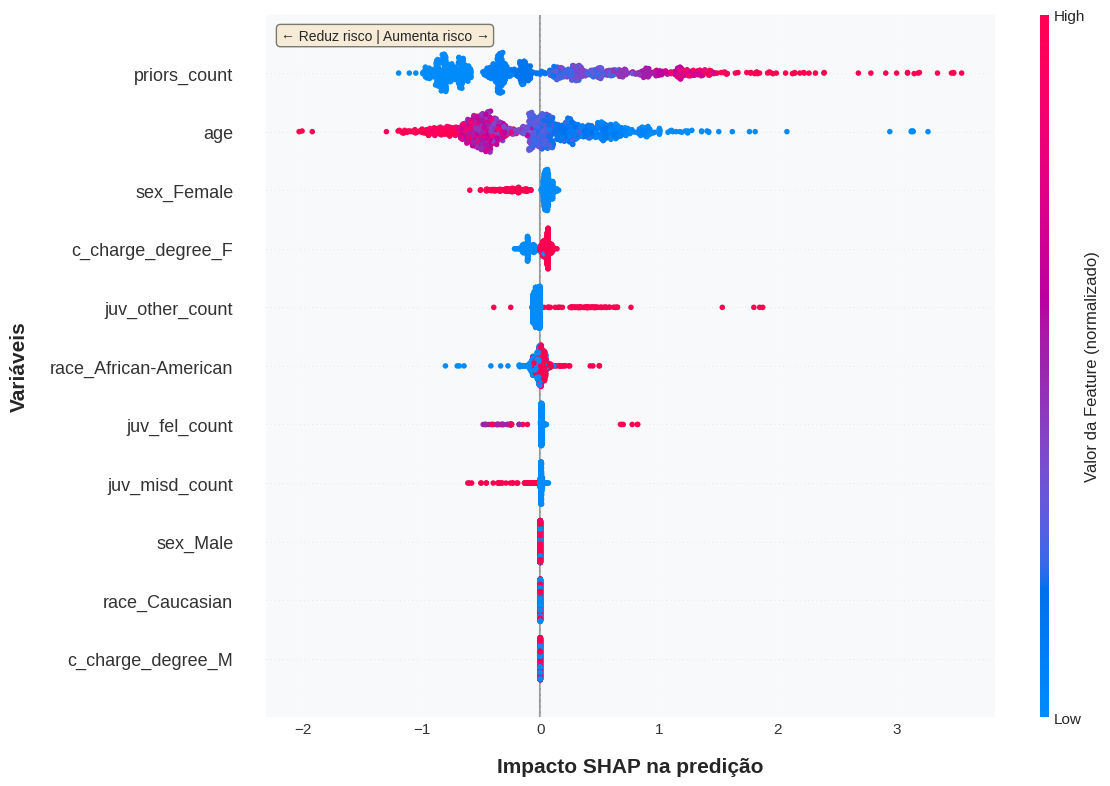

In [ ]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração global de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

# Configuração do Explainer
explainer = shap.TreeExplainer(model_base)
shap_values = explainer.shap_values(X_test)

# =============================================================================
# 1. VISÃO GLOBAL - BEESWARM PLOT MELHORADO
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=100)

shap.summary_plot(
    shap_values,
    X_test,
    show=False,
    plot_size=(12, 8),
    color_bar_label="Valor da Feature (normalizado)",
    max_display=15  # Limita para as 15 features mais importantes
)

# plt.title ("Importância das Variáveis na Predição de Reincidência\n",fontsize=16, fontweight='bold', pad=2)

# Adiciona anotação explicativa
plt.text(
    0.02, 0.98,
    "← Reduz risco | Aumenta risco →",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

plt.xlabel("Impacto SHAP na predição", fontsize=15, fontweight='bold', labelpad=15)
plt.ylabel("Variáveis", fontsize=15, fontweight='bold', labelpad=15)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('fig04.png', bbox_inches='tight', dpi=800)
plt.show()

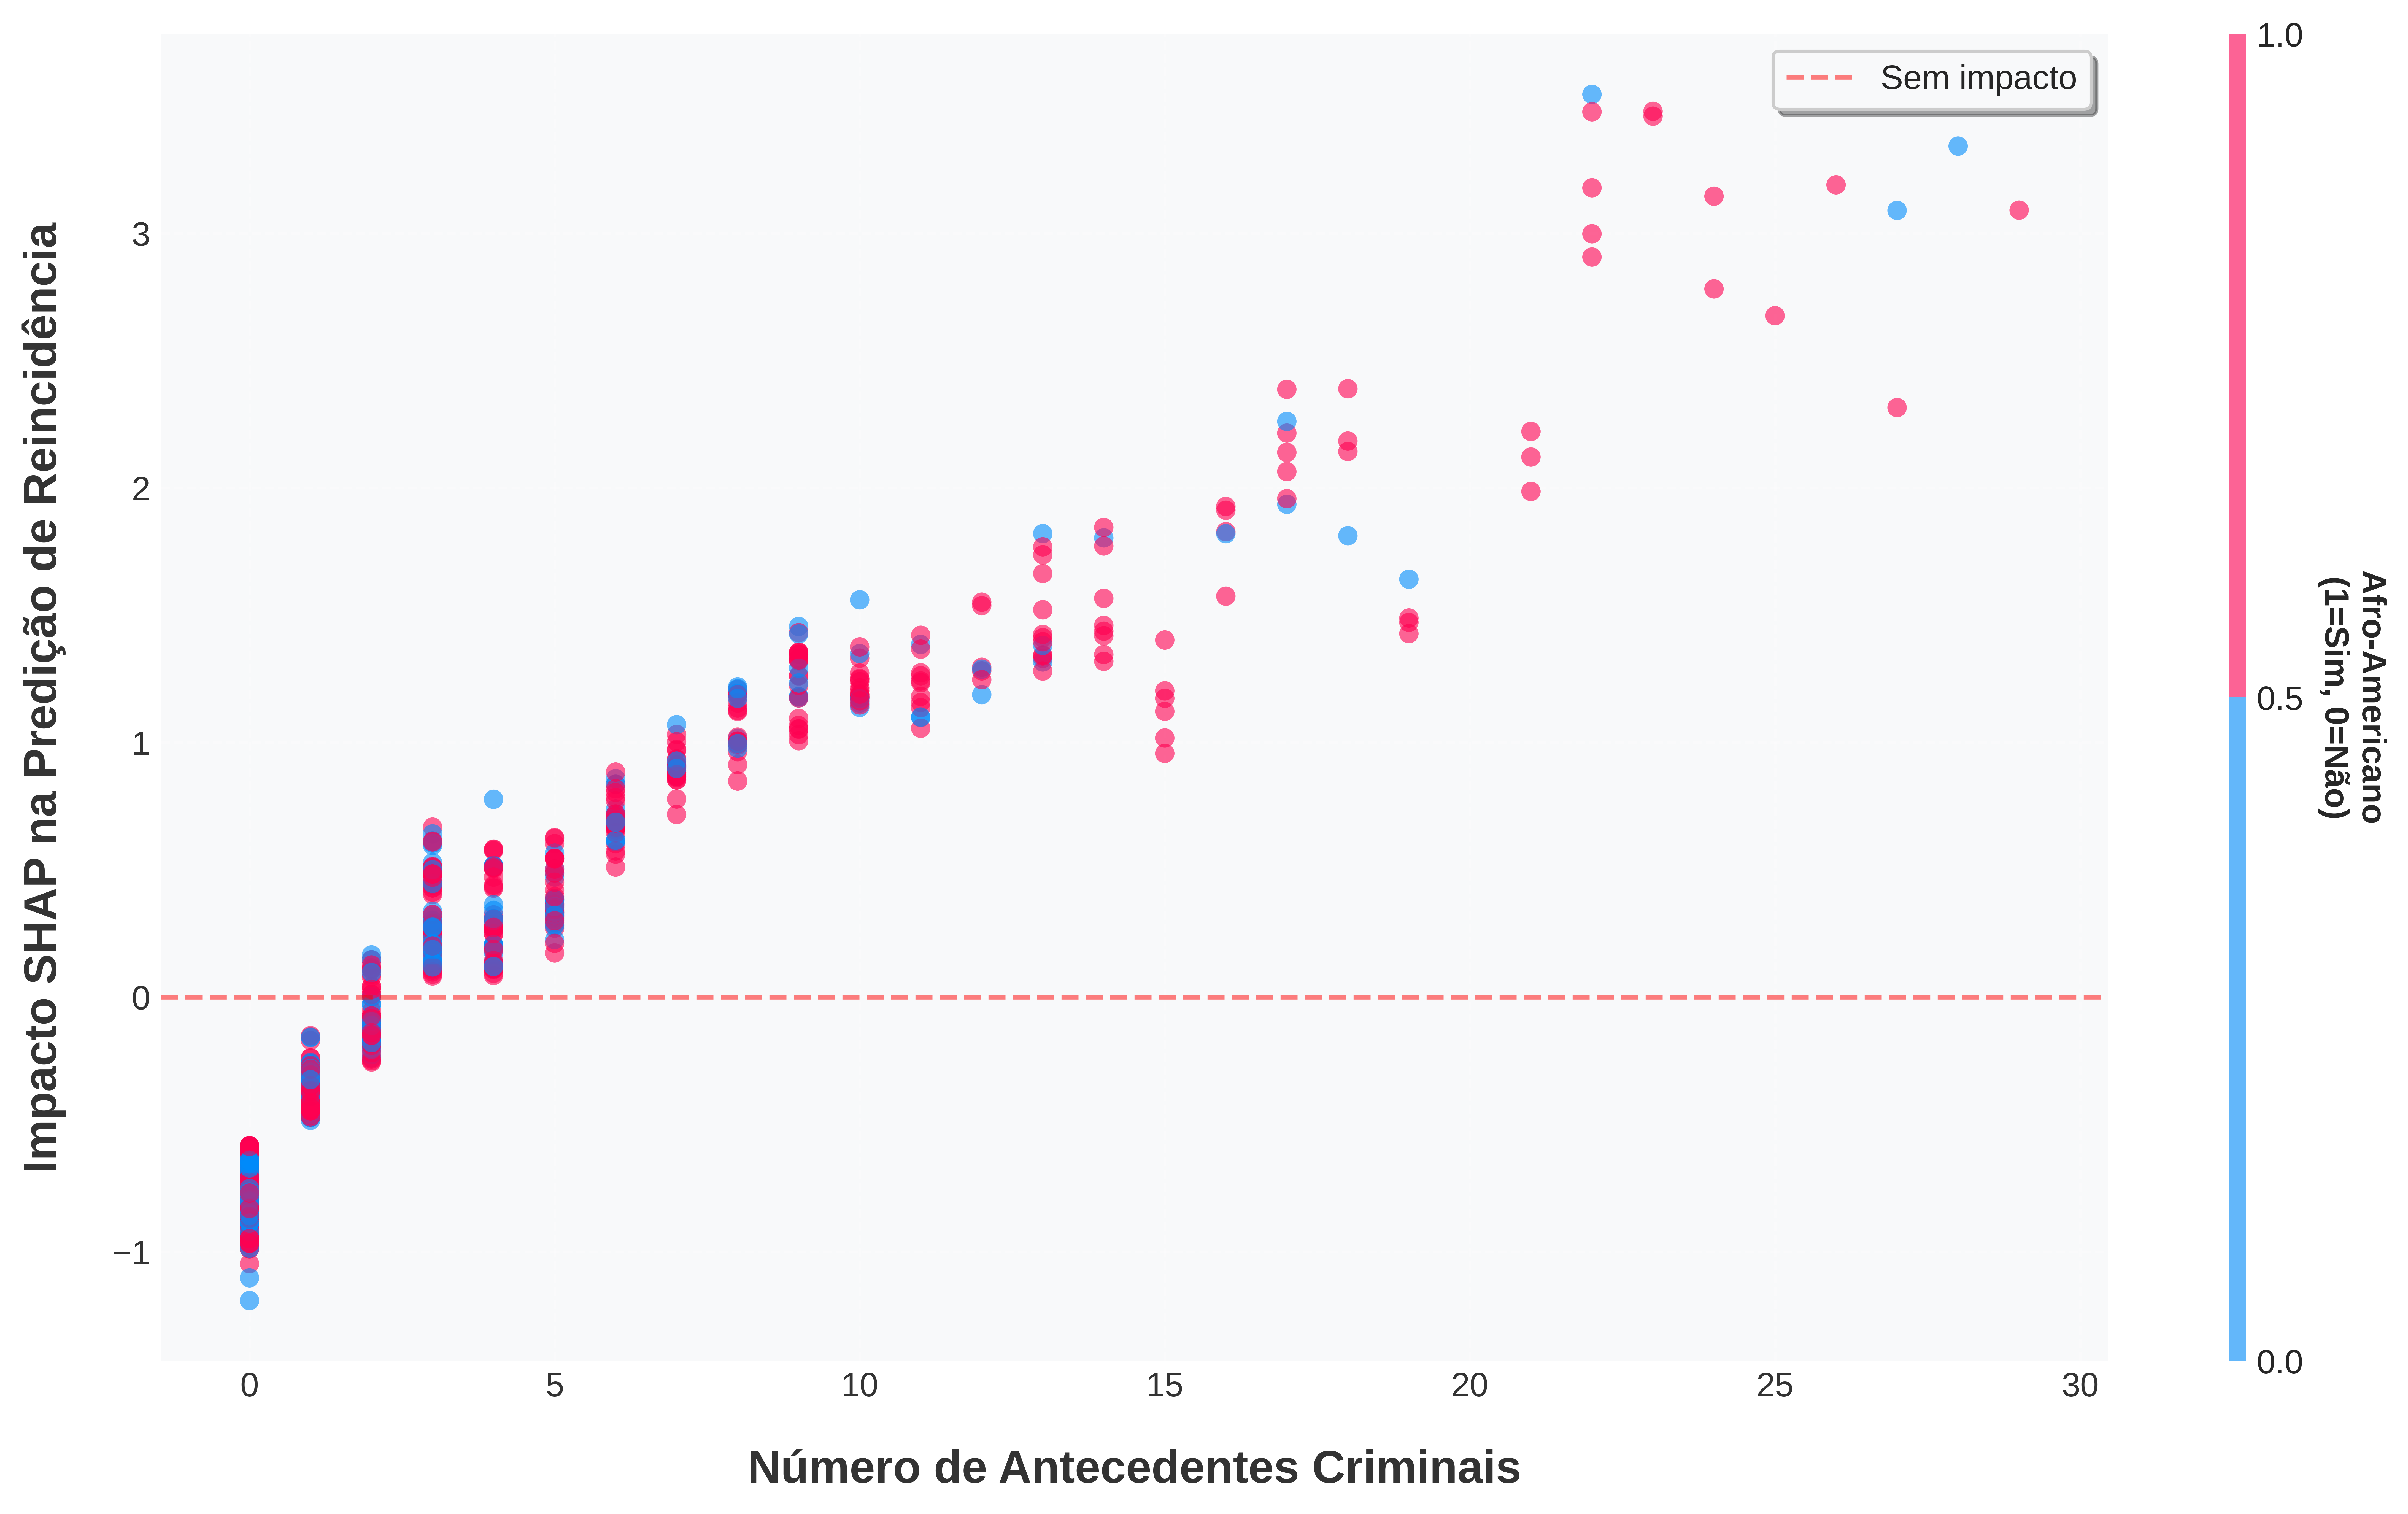

In [ ]:
# =============================================================================
# 2. ANÁLISE DE INTERAÇÃO - DEPENDENCE PLOT
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 7), dpi=800)

shap.dependence_plot(
    "priors_count",
    shap_values,
    X_test,
    interaction_index="race_African-American",
    show=False,
    ax=ax,
    dot_size=40,
    alpha=0.6
)

# plt.title( "Análise de Viés: Como a Raça Influencia o Peso dos Antecedentes Criminais?\n""Separação vertical indica tratamento desigual para o mesmo histórico", fontsize=14, fontweight='bold', pad=15)

plt.xlabel("Número de Antecedentes Criminais", fontsize=15, fontweight='bold', labelpad=15)
plt.ylabel("Impacto SHAP na Predição de Reincidência", fontsize=15, fontweight='bold', labelpad=15)

# Adiciona linha de referência em zero
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Sem impacto')

# Melhora a legenda da cor
cbar = plt.gcf().axes[-1]
cbar.set_ylabel(
    'Afro-Americano\n(1=Sim, 0=Não)',
    fontsize=11,
    fontweight='bold',
    rotation=270,
    labelpad=27
)

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='best', frameon=True, shadow=True)
plt.tight_layout()
plt.savefig('fig05.png', bbox_inches='tight', dpi=300)
plt.show()

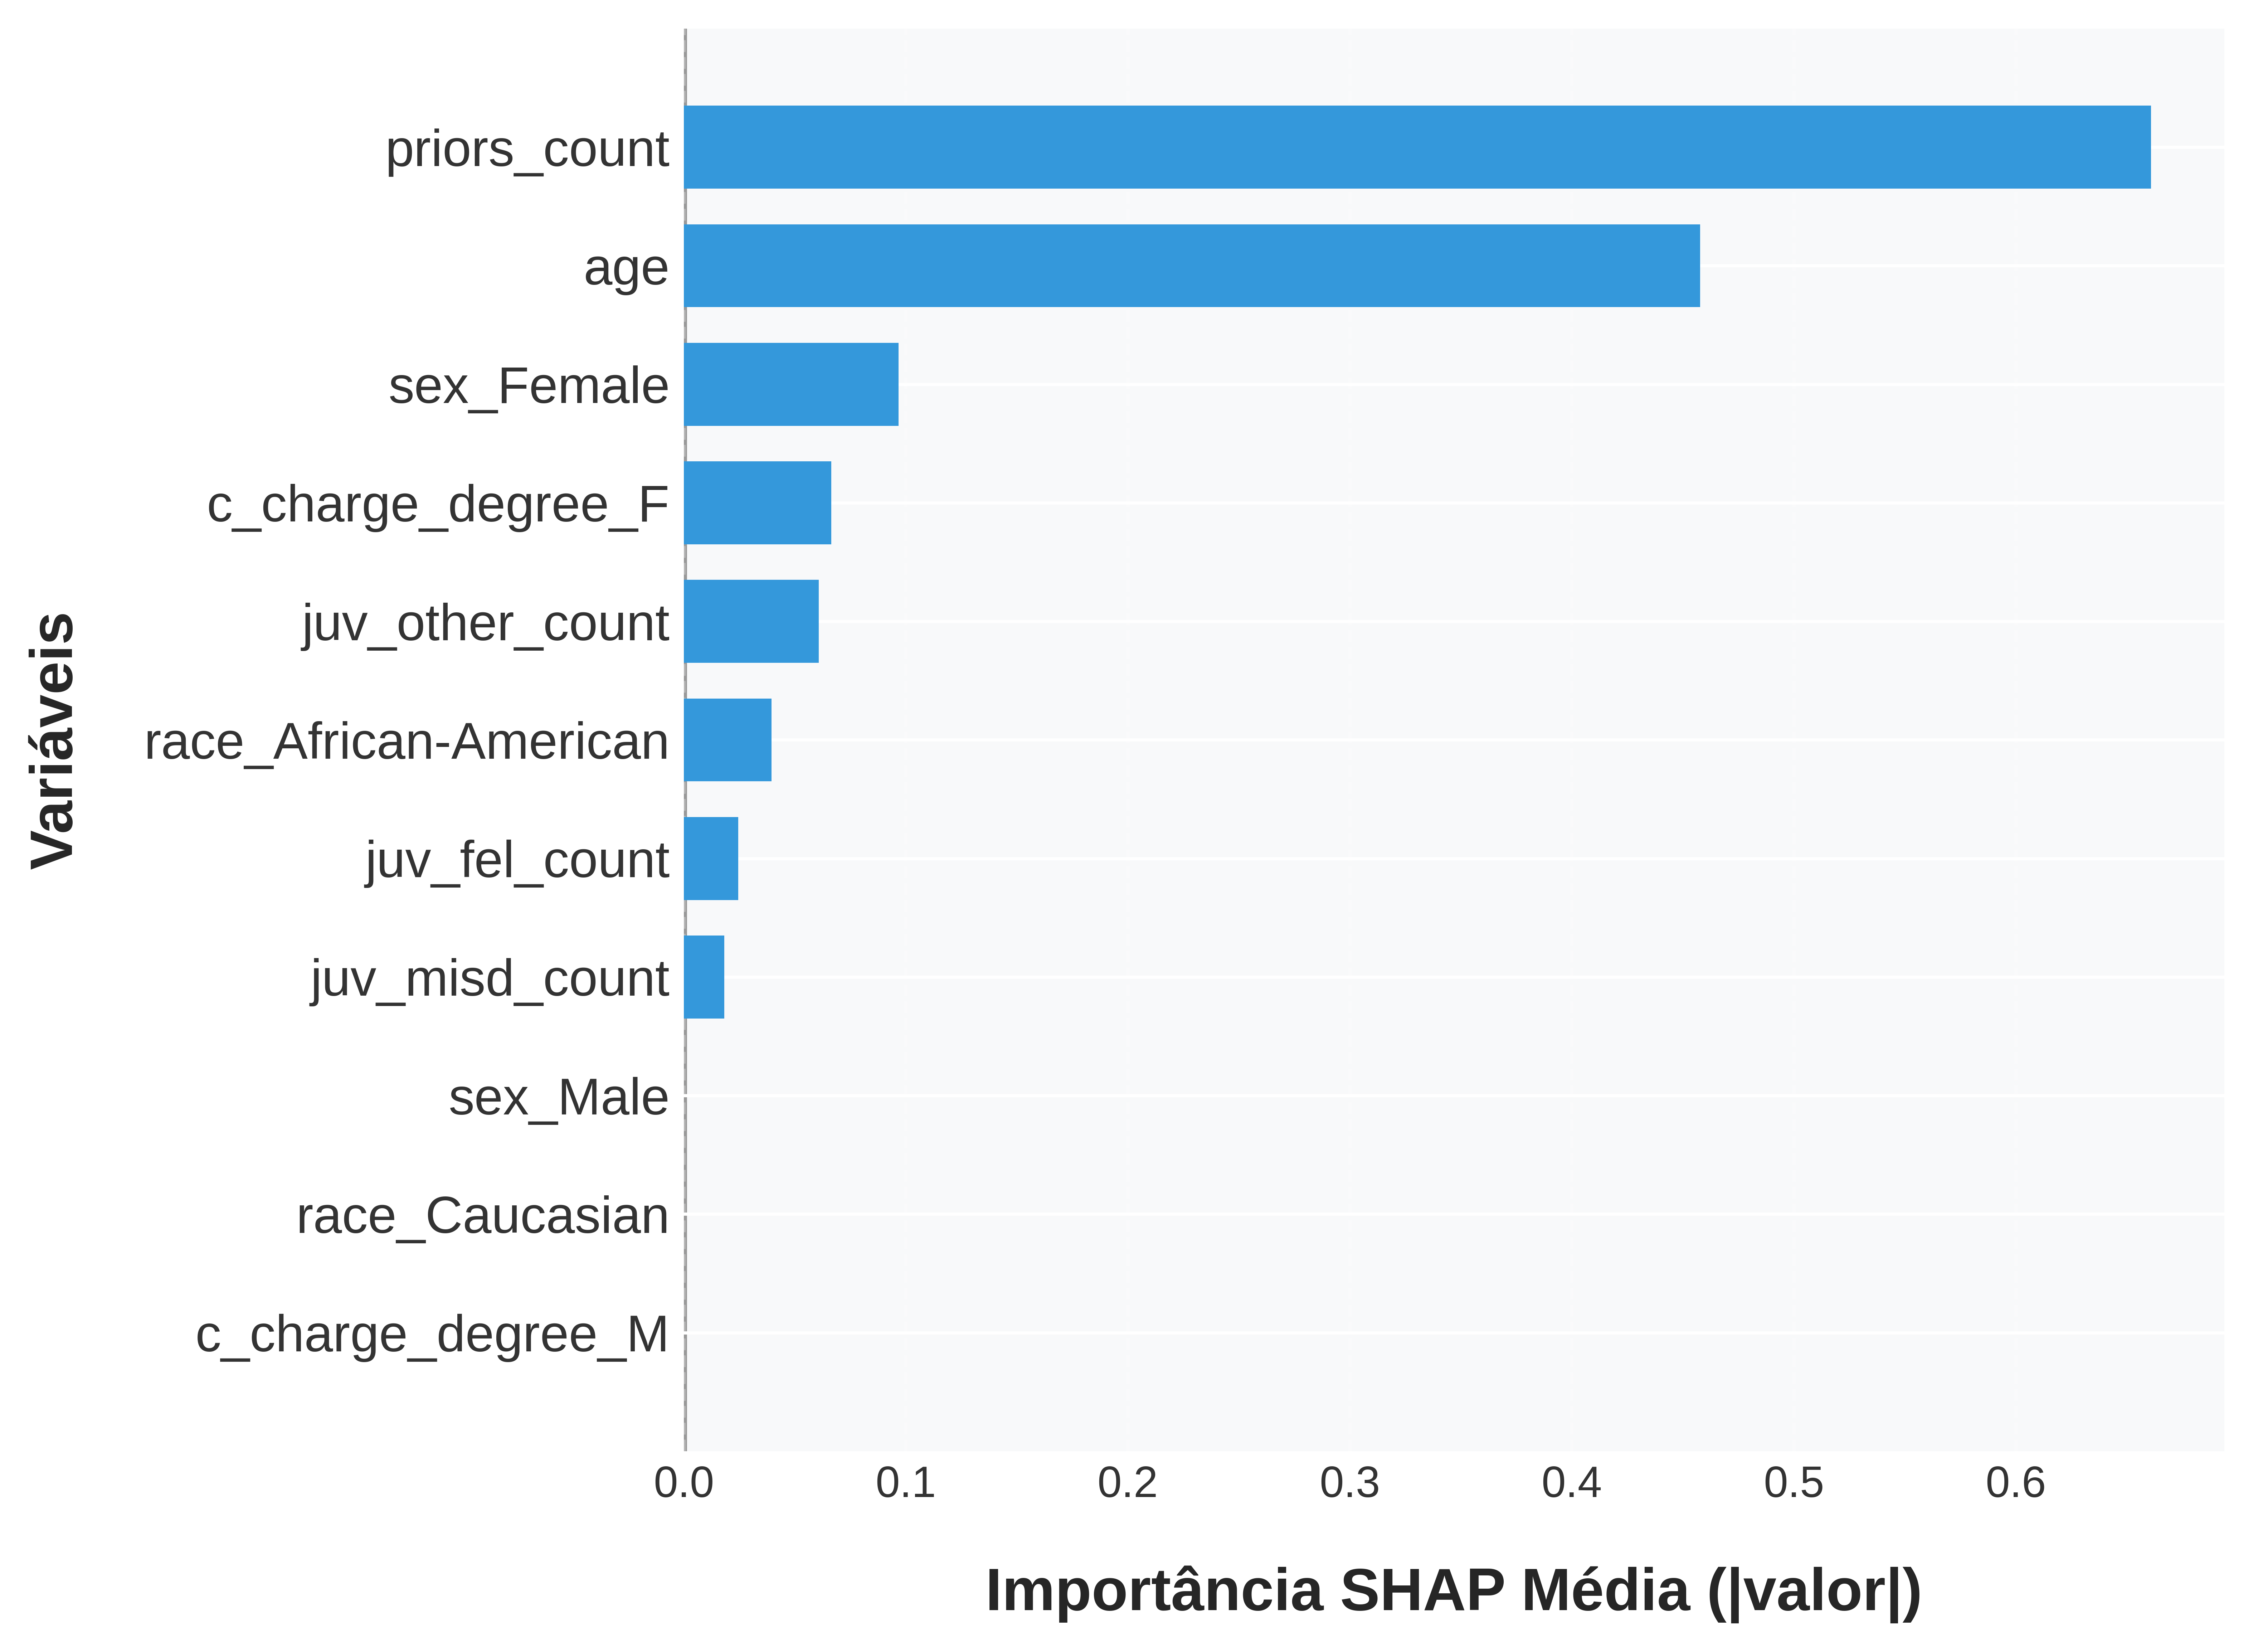

In [ ]:
# =============================================================================
# 4. BAR PLOT - IMPORTÂNCIA MÉDIA ABSOLUTA (EXTRA)
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 7), dpi=800)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False,
    max_display=15,
    color='#3498db'
)

# plt.title( "Ranking de Importância das Variáveis\n(Impacto Médio Absoluto)", fontsize=14, fontweight='bold', pad=15)

plt.xlabel("Importância SHAP Média (|valor|)", fontsize=15, fontweight='bold', labelpad=15)
plt.ylabel("Variáveis", fontsize=15, fontweight='bold', labelpad=15)
plt.grid(True, alpha=0.3, linestyle='--', axis='x')
plt.tight_layout()
plt.savefig('fig06.png', bbox_inches='tight', dpi=800)
plt.show()

In [ ]:
# =============================================================================
# 5. ANÁLISE DE VIÉS COMPARATIVA
# =============================================================================
# Compara o impacto de 'priors_count' entre grupos raciais
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=800)

# Filtra dados por raça
mask_african = X_test['race_African-American'] == 1
mask_other = X_test['race_African-American'] == 0

# Plot para Afro-Americanos
axes[0].scatter(
    X_test.loc[mask_african, 'priors_count'],
    shap_values[mask_african, X_test.columns.get_loc('priors_count')],
    alpha=0.5,
    s=50,
    c='#e74c3c',
    edgecolors='black',
    linewidth=0.5,
    label='Afro-Americanos'
)
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Impacto para Afro-Americanos', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('Número de Antecedentes', fontsize=15, fontweight='bold', labelpad=15)
axes[0].set_ylabel('Impacto SHAP', fontsize=15, fontweight='bold', labelpad=15)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].legend()

# Plot para outros grupos
axes[1].scatter(
    X_test.loc[mask_other, 'priors_count'],
    shap_values[mask_other, X_test.columns.get_loc('priors_count')],
    alpha=0.5,
    s=50,
    c='#3498db',
    edgecolors='black',
    linewidth=0.5,
    label='Outros Grupos'
)
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Impacto para Outros Grupos', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('Número de Antecedentes', fontsize=15, fontweight='bold', labelpad=15)
axes[1].set_ylabel('Impacto SHAP', fontsize=11, fontweight='bold', labelpad=15)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].legend()

# plt.suptitle('Análise Comparativa: Viés no Peso dos Antecedentes Criminais', fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('fig07.png', bbox_inches='tight', dpi=800)
plt.show()